In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [7]:
print("Rows & columns:", df.shape)

Rows & columns: (3000, 10)


In [5]:
df.columns


Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [9]:
print("Is there any null values:")
df.isnull().sum()

Is there any null values:


Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [10]:
print("Number of duplicate rows: ")
df.duplicated().sum()

Number of duplicate rows: 


np.int64(0)

In [11]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [12]:
df.nunique()

Country                                  10
Year                                     10
Attack Type                               6
Target Industry                           7
Financial Loss (in Million $)          2536
Number of Affected Users               2998
Attack Source                             4
Security Vulnerability Type               4
Defense Mechanism Used                    5
Incident Resolution Time (in Hours)      72
dtype: int64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Phishing'),
  Text(1, 0, 'Ransomware'),
  Text(2, 0, 'Man-in-the-Middle'),
  Text(3, 0, 'DDoS'),
  Text(4, 0, 'SQL Injection'),
  Text(5, 0, 'Malware')])

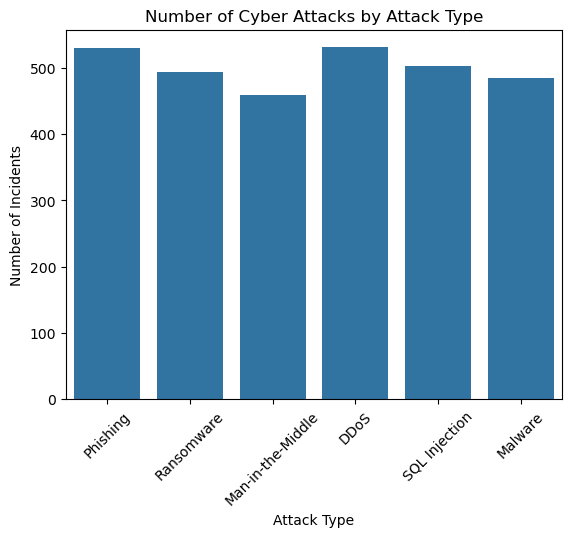

In [38]:
df['Attack Type'].value_counts()
sns.countplot(data = df, x = 'Attack Type')
plt.title('Number of Cyber Attacks by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation = 45)



In [39]:
# Which attack type caused the highest total financial loss in the dataset ?
df.groupby('Attack Type')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)


Attack Type
DDoS                 27630.92
Phishing             26693.29
SQL Injection        25156.56
Ransomware           24479.32
Malware              23967.95
Man-in-the-Middle    23550.87
Name: Financial Loss (in Million $), dtype: float64

In [40]:
# Which attack type has the highest average financial loss per incident ?
avg_loss = df.groupby('Attack Type')['Financial Loss (in Million $)'].mean().sort_values(ascending = False)


In [42]:
#Which industries are targeted most ?
industry_counts = df['Target Industry'].value_counts()
industry_counts

Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

In [43]:
# Which country have the most recorded incident ?
country_counts = df['Country'].value_counts()
country_counts

Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

In [44]:
# Where the recorded attacks came from ?
source_counts = df['Attack Source'].value_counts()
source_counts

Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

In [45]:
vulnerability_counts = df['Security Vulnerability Type'].value_counts()
vulnerability_counts

Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

In [46]:
defense_counts = df['Defense Mechanism Used'].value_counts()
defense_counts

Defense Mechanism Used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64

In [47]:
df['Incident Resolution Time (in Hours)'].describe()

count    3000.000000
mean       36.476000
std        20.570768
min         1.000000
25%        19.000000
50%        37.000000
75%        55.000000
max        72.000000
Name: Incident Resolution Time (in Hours), dtype: float64

In [51]:
## Which year had the highest number of recorded cyber incident, and how many incidents were record in that year ?
year_counts = df['Year'].value_counts().sort_index().sort_values(ascending = False)
year_counts

Year
2017    319
2022    318
2020    315
2023    315
2018    310
2021    299
2024    299
2016    285
2015    277
2019    263
Name: count, dtype: int64

In [52]:
# Which year had the lowest number of recorded cyber incident, and how many incidents were record in that year ?
year_counts = df['Year'].value_counts().sort_index().sort_values(ascending = True)
year_counts

Year
2019    263
2015    277
2016    285
2021    299
2024    299
2018    310
2020    315
2023    315
2022    318
2017    319
Name: count, dtype: int64

In [53]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [54]:
# What was the total number of affected user across all 3000 recorded incident3
df['Financial Loss (in Million $)'].sum()

np.float64(151478.91)

In [55]:
#What is the total number of affected user across all 3000 record incident ?
df['Number of Affected Users'].sum()

np.int64(1514052409)

In [56]:
#Which attack type affected the highest total number of users ?
df.groupby('Attack Type')['Number of Affected Users'].sum()

Attack Type
DDoS                 265201265
Malware              246758413
Man-in-the-Middle    238709523
Phishing             257717975
Ransomware           247892907
SQL Injection        257772326
Name: Number of Affected Users, dtype: int64

In [57]:
# Which attack type had the highest average number of affected users per incident ?
df.groupby('Attack Type')['Number of Affected Users'].mean()

Attack Type
DDoS                 499437.410546
Malware              508780.232990
Man-in-the-Middle    520064.320261
Phishing             487179.536862
Ransomware           502825.369168
SQL Injection        512469.833002
Name: Number of Affected Users, dtype: float64

In [59]:
# Which country has the highest total financial loss in the dataset ?
df.groupby('Country')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Country
UK           16502.99
Germany      15793.24
Brazil       15782.62
Australia    15403.00
Japan        15197.34
France       14972.28
USA          14812.12
Russia       14734.73
India        14566.12
China        13714.47
Name: Financial Loss (in Million $), dtype: float64

In [62]:
# Which country has the highest total number of affected users ?
df.groupby('Country')['Number of Affected Users'].sum().sort_values(ascending = False)

Country
Brazil       168806980
UK           157464983
France       156229142
Russia       152191835
Australia    150011830
India        149178659
Japan        148711814
Germany      147675358
USA          144200870
China        139580938
Name: Number of Affected Users, dtype: int64

In [63]:
# Which attack type has the longest average incident resolution time ?
df.groupby('Attack Type')['Incident Resolution Time (in Hours)'].mean()

Attack Type
DDoS                 35.687382
Malware              37.074227
Man-in-the-Middle    36.871460
Phishing             35.913043
Ransomware           36.533469
SQL Injection        36.906561
Name: Incident Resolution Time (in Hours), dtype: float64

In [65]:
# Which security vulnerability type has the highest total financial loss ?
df.groupby('Security Vulnerability Type')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Security Vulnerability Type
Zero-day              39548.54
Social Engineering    38026.54
Unpatched Software    37024.43
Weak Passwords        36879.40
Name: Financial Loss (in Million $), dtype: float64

In [66]:
# Which target industry has the highest total financial loss ?
df.groupby('Target Industry')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Target Industry
IT                    24809.83
Banking               22772.39
Government            21205.33
Retail                21119.55
Healthcare            21041.29
Telecommunications    20459.09
Education             20071.43
Name: Financial Loss (in Million $), dtype: float64

In [67]:
# Which defence mechanism used has the highest average incident resolution time ?
df.groupby('Defense Mechanism Used')['Incident Resolution Time (in Hours)'].mean().sort_values(ascending = False)

Defense Mechanism Used
VPN                   36.864379
AI-based Detection    36.612350
Encryption            36.589527
Antivirus             36.573248
Firewall              35.714530
Name: Incident Resolution Time (in Hours), dtype: float64

In [70]:
# Which country has the highest number of recorded incident ?
df['Country'].value_counts().sort_values(ascending = False)

Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

In [3]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [4]:
# Which year had the highest total financial loss ?
df.groupby('Year')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Year
2017    16261.68
2023    15958.08
2021    15873.41
2022    15870.86
2020    15767.95
2024    15434.29
2018    14720.48
2015    14510.21
2016    13947.26
2019    13134.69
Name: Financial Loss (in Million $), dtype: float64

In [5]:
# Which year had the lowest total financial loss ?
df.groupby('Year')['Financial Loss (in Million $)'].sum().sort_values(ascending = True)

Year
2019    13134.69
2016    13947.26
2015    14510.21
2018    14720.48
2024    15434.29
2020    15767.95
2022    15870.86
2021    15873.41
2023    15958.08
2017    16261.68
Name: Financial Loss (in Million $), dtype: float64

In [6]:
#Which country had the highest total number of affected users ?
df.groupby('Country')['Number of Affected Users'].sum().sort_values(ascending = False)

Country
Brazil       168806980
UK           157464983
France       156229142
Russia       152191835
Australia    150011830
India        149178659
Japan        148711814
Germany      147675358
USA          144200870
China        139580938
Name: Number of Affected Users, dtype: int64

In [9]:
# Which combination of attack type and target industries has the highest number of record incident ?
df.groupby(['Attack Type', 'Target Industry']).size().sort_values(ascending = False)

Attack Type        Target Industry   
Phishing           Banking               96
DDoS               IT                    91
Phishing           Retail                89
                   IT                    89
DDoS               Telecommunications    85
Malware            Healthcare            81
Man-in-the-Middle  IT                    80
SQL Injection      Telecommunications    78
DDoS               Healthcare            78
SQL Injection      IT                    77
Man-in-the-Middle  Banking               77
Ransomware         Healthcare            77
SQL Injection      Government            75
Malware            Telecommunications    74
Ransomware         IT                    74
DDoS               Education             73
Phishing           Education             73
SQL Injection      Healthcare            72
Ransomware         Government            72
DDoS               Government            71
SQL Injection      Banking               71
Ransomware         Retail             

In [11]:
# Which security vulnerability type has the highest average financial loss per incident ?
df.groupby('Security Vulnerability Type')['Financial Loss (in Million $)'].mean().sort_values(ascending = False)

Security Vulnerability Type
Social Engineering    50.905676
Weak Passwords        50.519726
Zero-day              50.380306
Unpatched Software    50.168604
Name: Financial Loss (in Million $), dtype: float64

In [12]:
#Which country has the highest average financial loss per cyber attack incident ?
df.groupby('Country')['Financial Loss (in Million $)'].mean().sort_values(ascending = False)

Country
Germany      54.272302
Australia    51.861953
USA          51.610174
UK           51.411184
Brazil       50.911677
Russia       49.948237
Japan        49.827344
France       49.089443
China        48.805943
India        47.292597
Name: Financial Loss (in Million $), dtype: float64

In [13]:
# Which attack source has the highest total financial loss in the dataset ?
df.groupby('Attack Source')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Attack Source
Nation-state    40497.22
Unknown         38810.61
Insider         36673.51
Hacker Group    35497.57
Name: Financial Loss (in Million $), dtype: float64

In [15]:
# Which defence mechanism has the highest total financial loss associated with the incident where it was used ?
df.groupby('Defense Mechanism Used')['Financial Loss (in Million $)'].sum().sort_values(ascending = False)

Defense Mechanism Used
Antivirus             32466.87
VPN                   30728.32
Encryption            29836.92
AI-based Detection    29360.77
Firewall              29086.03
Name: Financial Loss (in Million $), dtype: float64

In [16]:
# Which year had the highest average financial loss for cyber attack incident ?
df.groupby('Year')['Financial Loss (in Million $)'].mean().sort_values(ascending = False)

Year
2021    53.088328
2015    52.383430
2024    51.619699
2017    50.977053
2023    50.660571
2020    50.056984
2019    49.941787
2022    49.908365
2016    48.937754
2018    47.485419
Name: Financial Loss (in Million $), dtype: float64

In [17]:
# Which year had the highest total number of affected users ?
df.groupby('Year')['Number of Affected Users'].sum().sort_values(ascending = False)

Year
2022    163263160
2017    161807880
2020    159036761
2021    155241999
2023    154305656
2024    153081317
2018    151774954
2016    144034584
2015    141293170
2019    130212928
Name: Number of Affected Users, dtype: int64

In [18]:
# Is there a relationship between financial loss and the number of affected users ?
correlation = df['Financial Loss (in Million $)'].corr(df['Number of Affected Users'])
correlation

np.float64(0.0017867355720258384)

In [19]:
# Are there any unusual high financial loss incident in the dataset ?
Q1 = df['Financial Loss (in Million $)'].quantile(0.25)
Q3 = df['Financial Loss (in Million $)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 25.7575
Q3: 75.63
IQR: 49.872499999999995
Lower Bound: -49.05124999999999
Upper Bound: 150.43874999999997


In [20]:
outliers = df[df['Financial Loss (in Million $)'] > upper_bound]
print("Number of high-loss outliers:", len(outliers))

Number of high-loss outliers: 0


In [ ]:
# What are the most important findings from our entire EDA That should go into a power bay dashboard